# Classification Using Decision Trees
CS-2104 Problem Solving in Computer Science

Week 14

A few markdown cells are adopted from the notebook of Dr. Chris North

Topics: 
* Classifier models: Decision Trees, Random Forests; 
* Evaluating Confusion matrix, Precision & Recall

Data:  sklearn.datasets.load_iris()


# Classification Problem

Should "?" be classified as an "X" or an "O"?

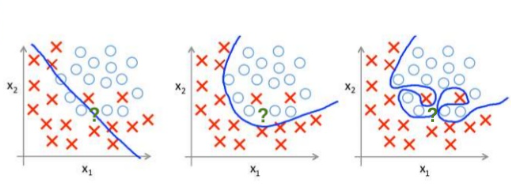

* Which class is a data instance a member of?
* Given data labeled with class memberships, learn to predict class of new data.
* Binary, Multi-class

### Machine Learning pipeline

1. Training
2. Testing
3. Prediction

<img src="https://labelyourdata.com/img/article-illustrations/training-data.png" width='400px'>


### Many classifier models:  
* Decision Trees, Random Forests
* kNN
* SVM
* ...


## Decision Trees

Focuses on the features (columns)

### Process

- For each attribute in the dataset, the decision tree algorithm forms a node, where the most important attribute is placed at the root node. 
- For evaluation we start at the root node and work our way down the tree by following the corresponding node that meets our condition or "decision". 
- This process continues until a leaf node is reached, which contains the prediction or the outcome of the decision tree.

### Example Scenario

A person asks you to lend them your car for a day, and you have to make a decision whether or not to lend them the car. There are several factors that help determine your decision:

1. Is this person a close friend or just an acquaintance? If the person is just an acquaintance, then decline the request; if the person is friend, then move to next step.
2. Is the person asking for the car for the first time? If they've bugged you before, decline, otherwise move to next step.
3. Was the car damaged last time they returned the car? If yes, decline the request; if no, lend them the car.

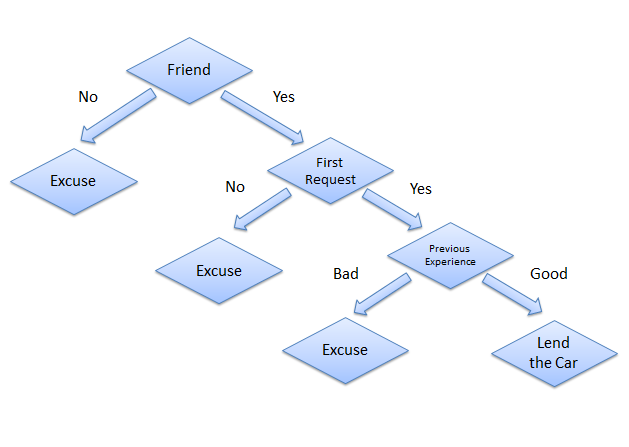

### Advantages of Decision Trees

1. They are inherintly Explainable,  easy to understand.
1. They can be used to classify non-linearly separable data.
1. Decision trees can be used to predict both continuous and discrete values i.e. they work well for both regression and classification tasks.
1. They require relatively low effort for training the algorithm.

### Disadvantages
1. Can be unstable
1. Can overfit

### Python
* https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
* https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html#sphx-glr-auto-examples-tree-plot-unveil-tree-structure-py


### Introduction to the Iris Dataset

The **Iris flower dataset**, also known as **Fisher’s Iris dataset**, is a classic multivariate dataset introduced by British statistician, eugenicist, and biologist **Ronald Fisher** in his 1936 paper *"The use of multiple measurements in taxonomic problems"*.

It was originally used as an example for **linear discriminant analysis** and remains one of the most popular datasets for testing classification algorithms.

---

![Iris Dataset Overview](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*uo6VfVH87jRjMZWVdwq3Vw.png)

*(Source: [Medium article](https://medium.com/@Nivitus./iris-flower-classification-machine-learning-d4e337140fa4))*


#### Example:  Classify Iris flowers

In [1]:
###
# Import necessary libraries
import pandas 
import numpy


import matplotlib.pyplot as plt

# Import datasets module from scikit-learn
import sklearn.datasets 

# Load the Iris dataset from scikit-learn's datasets
iris = sklearn.datasets.load_iris()

In [2]:
###
# Create a DataFrame 'x' containing the feature data from the iris dataset
# The columns are named according to the feature names provided in the dataset
x = pandas.DataFrame(iris.data, columns=iris.feature_names)

# Create a Series 'y' containing the target labels (species)
# Map each numeric label to its corresponding species name for better readability
y = pandas.Series(iris.target, name='Species').map(lambda s: iris.target_names[s])

# Display the DataFrame 'x' (feature data)
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [3]:
# Display the Series 'y', which contains the species names for each sample
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: Species, Length: 150, dtype: object

In [4]:
# Count the number of occurrences of each species in the dataset
y.value_counts()

Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

<Axes: >

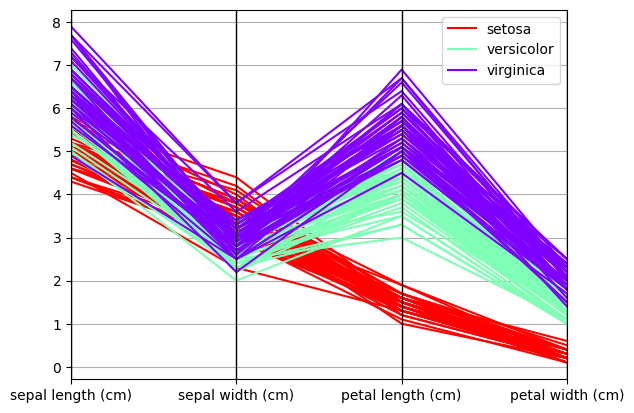

In [5]:
# Create a parallel coordinates plot to visualize feature relationships across different species
# 'x' and 'y' are joined to form a single DataFrame, with 'Species' used to color the lines
# 'colormap' defines the color range for different species
pandas.plotting.parallel_coordinates(x.join(y), 'Species', colormap=plt.cm.rainbow_r)

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

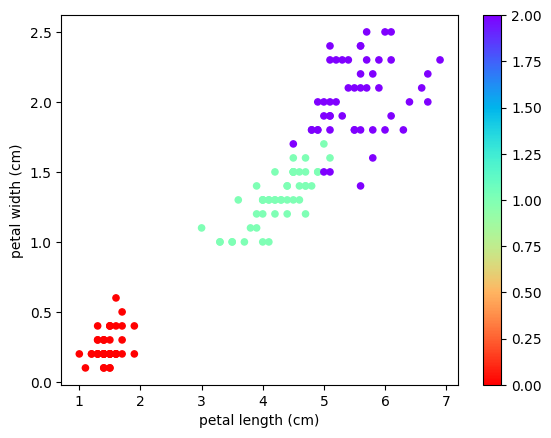

In [6]:
# Create a scatter plot of petal length vs. petal width
# Points are colored based on species using the target values
# 'cmap' applies a rainbow color map to distinguish species
# 'sharex=False' ensures the x-axis is not shared if part of a subplot (optional here)
x.plot.scatter('petal length (cm)', 'petal width (cm)', c=iris.target, cmap=plt.cm.rainbow_r, sharex=False)

#### Decision Tree Hyper-Parameters:

* **criterion:** How the impurity of a split will be measured. The default value is “gini” but you can also use “entropy” as a metric for impurity.

* **splitter:** This is how the decision tree searches the features for a split. 

* **max_depth:** This determines the maximum depth of the tree. 

* **min_samples_split:** The minimum number of samples a node must contain in order to consider splitting. 

* **min_samples_leaf:** The minimum number of samples needed to be considered a leaf node. 

* **max_features:** The number of features to consider when looking for the best split.

In [7]:
# Import the decision tree module from scikit-learn
import sklearn.tree 

# Create a Decision Tree Classifier with a maximum depth of 2
tree = sklearn.tree.DecisionTreeClassifier(max_depth=2)

# Train (fit) the decision tree model using feature data 'x' and target labels 'y'
tree.fit(x, y)

# Please note various parameters

DecisionTreeClassifier(max_depth=2)

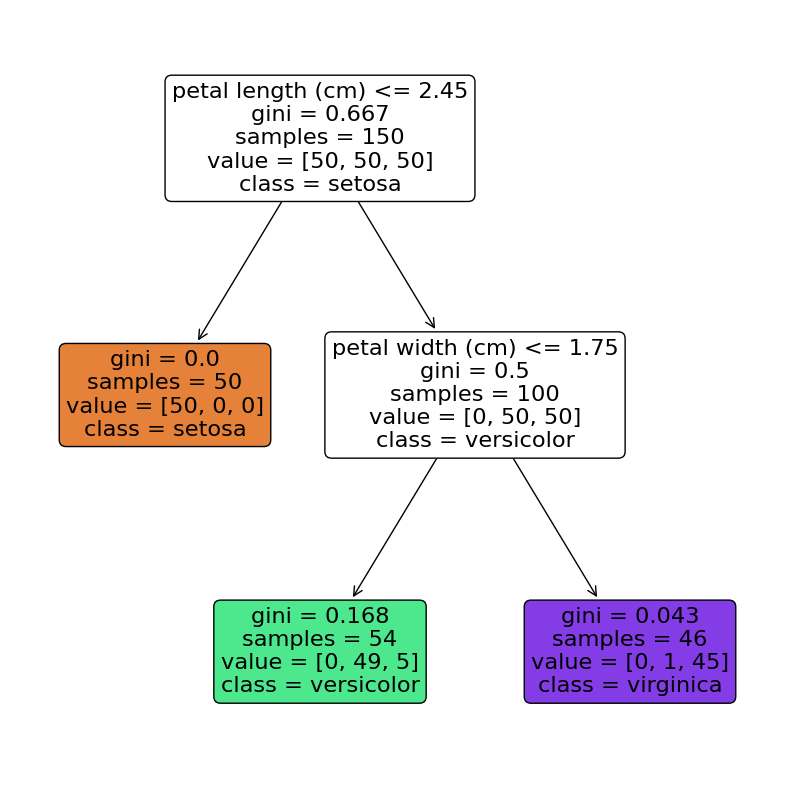

In [8]:
# Set the figure size for better visibility of the decision tree plot
plt.figure(figsize=(10,10))

# Plot the trained decision tree
# 'filled=True' fills the nodes with colors based on the class
# 'rounded=True' makes node boxes rounded
# 'feature_names' labels the features used at each split
# 'class_names' labels the classes at the leaves
a = sklearn.tree.plot_tree(tree, filled=True, rounded=True, 
                           feature_names=list(tree.feature_names_in_),
                           class_names=list(tree.classes_))

### Gini impurity score

What is Gini Impurity?
Gini impurity measures how often a randomly chosen element from the set would be incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset. The gini score is a metric that quantifies the impurity of the node. 

Low Gini → mostly pure (only one class)
High Gini → very mixed (many classes)


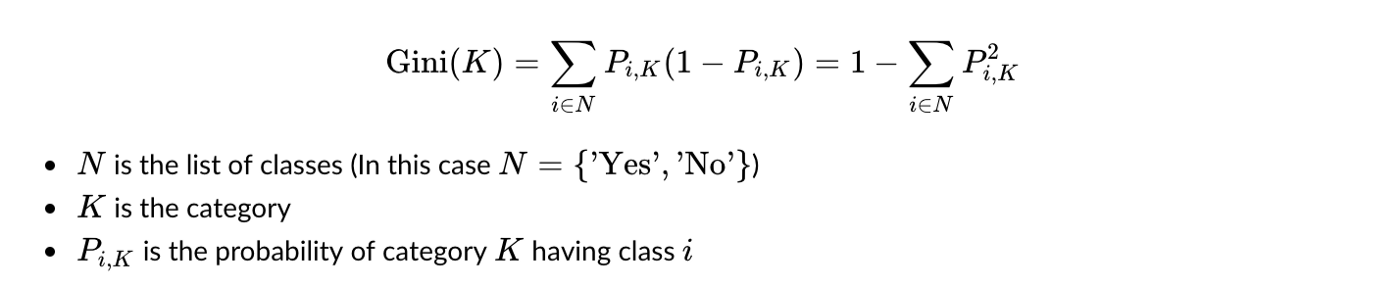

* Gini == 0 : the node is pure, that within that node only a single class of samples exist. 
* Gini > 0 : samples contained within are distributed into different classes.


In [9]:
# Calculate the Gini score of setosa prediction
# There are 50 samples total: 50 setosa, 0 versicolor, 0 virginica
# Gini = 1 - (probability of setosa)^2 - (probability of versicolor)^2 - (probability of virginica)^2
# Since all samples belong to one class, the Gini score will be 0 (pure node)
1 - (50/50)**2 - (0/50)**2 - (0/50)**2

0.0

In [10]:
# Calculate the Gini score of versicolor prediction
# There are 54 samples total: 0 samples of class 1, 49 samples of class 2, and 5 samples of class 3
# Gini = 1 - (probability of class 1)^2 - (probability of class 2)^2 - (probability of class 3)^2
1-(0/54)**2 - (49/54)**2 - (5/54)**2

0.1680384087791495

In [ ]:
# Calculate the Gini score of virginica prediction
# Calculate here
#There are 46 samples total: 0 samples of class 1, 14 samples of class 2, and 32 samples of class 3
# Gini = 1 - (probability of class 1)^2 - (probability of class 2)^2 - (probability of class 3)^2
1-(0/46)**2 - (14/46)**2 - (32/46)**2

### Confusion Matrix

In [12]:
from sklearn.metrics import confusion_matrix

# Predict using your trained tree
y_pred = tree.predict(x)

# Create confusion matrix
cm = confusion_matrix(y, y_pred, labels=tree.classes_)
print(cm)

[[50  0  0]
 [ 0 49  1]
 [ 0  5 45]]


|                   | Predicted Setosa | Predicted Versicolor | Predicted Virginica |
|-------------------|------------------|----------------------|---------------------|
| **True Setosa**     | 50               | 0                    | 0                   |
| **True Versicolor** | 0                | 49                   | 1                   |
| **True Virginica**  | 0                | 5                    | 45                  |

### Precision, Recall, and F1-Score

**Precision** measures how many of the predicted positive samples are actually positive:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**Recall** measures how many of the actual positive samples were correctly predicted:

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**F1-Score** is the harmonic mean of Precision and Recall:

$$
\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

Where:
- **TP** = True Positives
- **FP** = False Positives
- **FN** = False Negatives

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y, y_pred, average=None, labels=tree.classes_)
print("Precision for each class:")
for label, score in zip(tree.classes_, precision):
    print(f"{label}: {score:.2f}")

Precision for each class:
setosa: 1.00
versicolor: 0.91
virginica: 0.98


In [14]:
recall = recall_score(y, y_pred, average=None, labels=tree.classes_)
print("\nRecall for each class:")
for label, score in zip(tree.classes_, recall):
    print(f"{label}: {score:.2f}")


Recall for each class:
setosa: 1.00
versicolor: 0.98
virginica: 0.90


In [15]:
f1 = f1_score(y, y_pred, average=None, labels=tree.classes_)
print("\nF1-Score for each class:")
for label, score in zip(tree.classes_, f1):
    print(f"{label}: {score:.2f}")


F1-Score for each class:
setosa: 1.00
versicolor: 0.94
virginica: 0.94


### Prediction

In [16]:
# predict for new data
tree.predict([[5, 5, 2, 1]])

/home/ugrads/majors/ushnahk/CS2104/.venv/lib64/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['setosa'], dtype=object)

In [17]:
tree.predict([[5, 5, 3, 1]])

/home/ugrads/majors/ushnahk/CS2104/.venv/lib64/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['versicolor'], dtype=object)

In [18]:
tree.predict([[5, 5, 3, 2]])

/home/ugrads/majors/ushnahk/CS2104/.venv/lib64/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['virginica'], dtype=object)

## Random Forests

We saw that decision trees are fairly unstable, dependent on the data, the height, and a variety of other parameters.  So why not create a bunch of decision trees and then let majority rule?

Process:
1.  Select random samples from a given dataset.
2.  Construct a decision tree for each sample and get a prediction result from each decision tree.
3.  Perform a vote for each predicted result.
4.  Select the prediction result with the most votes as the final prediction.

![Decision Tree and Random Forest Diagram](https://almablog-media.s3.ap-south-1.amazonaws.com/image_26_d14c96fe3a.png)



### Advantages:

1.  Random forests is considered as a highly accurate and robust method because of the number of decision trees participating in the process.
2.  It does not suffer from the overfitting problem. The main reason is that it takes the average of all the predictions, which cancels out the biases.
3.  The algorithm can be used in both classification and regression problems.
4.  Random forests can also handle missing values. There are two ways to handle these: using median values to replace continuous variables, and computing the proximity-weighted average of missing values.
5.  You can get the relative feature importance, which helps in selecting the most contributing features for the classifier.

### Disadvantages:

1.  A random forest is slow in generating predictions because it has multiple decision trees. Whenever it makes a prediction, all the trees in the forest have to make a prediction for the same given input and then perform voting on it. This whole process is time-consuming.
2.  The model is difficult to interpret compared to a decision tree, where you can easily make a decision by following the path in the tree.